In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Load dataset

In [2]:
df = pd.read_csv('formatted_data.csv')
df.head()

,Brand,Model,YOM,Mileage,Gear,Fuel Type,Engine (cc),Condition,Ad Date,Location,...,Number of Cylinders,Power Steering,Power Shutters,Power Mirrors,Manufacturing Country,Model_cleaned,Mileage_numeric,Price_numeric,Ad_Date_Clean_Str,Ad_Date_clean
0,Audi,A3 Sline,2018,93000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jun 05, 11:39 am",Colombo,...,3.0,Yes,Yes,Yes,Germany,a3sline,93000.0,14400000.0,2026 Jun 05,2026-06-05
1,Audi,A1 Sline,2017,96000.0,Automatic,Petrol,990.0,Registered (Used),"2026 Jun 06, 10:27 pm",Kandy,...,3.0,Yes,Yes,Yes,Germany,a1sline,96000.0,8650000.0,2026 Jun 06,2026-06-06
2,Audi,A1 Highest Spec,2016,86000.0,Automatic,Petrol,10000.0,Registered (Used),"2026 Jul 19, 9:58 am",Colombo,...,6.0,Yes,Yes,Yes,Germany,a1highestspec,86000.0,8200000.0,2026 Jul 19,2026-07-19
3,Audi,A1,2017,69000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 27, 5:36 pm",Bandaragama,...,3.0,Yes,Yes,Yes,Germany,a1,69000.0,8700000.0,2026 Jul 27,2026-07-27
4,Audi,A1,2016,55000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 28, 12:06 am",Bandaragama,...,3.0,Yes,Yes,Yes,Germany,a1,55000.0,9500000.0,2026 Jul 28,2026-07-28


Data cleaning


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6436 entries, 0 to 6435
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Brand                  6436 non-null   object 
 1   Model                  6436 non-null   object 
 2   YOM                    6436 non-null   int64  
 3   Mileage                6418 non-null   float64
 4   Gear                   6436 non-null   object 
 5   Fuel Type              6436 non-null   object 
 6   Engine (cc)            6258 non-null   float64
 7   Condition              6436 non-null   object 
 8   Ad Date                6436 non-null   object 
 9   Location               6436 non-null   object 
 10  Price                  6436 non-null   object 
 11  URL                    6436 non-null   object 
 12  Body Type              6436 non-null   object 
 13  Number of Cylinders    6218 non-null   float64
 14  Power Steering         6436 non-null   object 
 15  Powe

In [4]:
df['Price_numeric'].isna().sum()

np.int64(1440)

In [5]:
df.dropna(subset=['Price_numeric'], inplace=True)
df['Price_numeric'].isna().sum()

np.int64(0)

In [6]:
df['Mileage_numeric'].isna().sum()

np.int64(8)

In [7]:
df.dropna(subset=['Mileage_numeric'], inplace=True)
df['Mileage_numeric'].isna().sum()

np.int64(0)

In [8]:
df['Number of Cylinders'].isna().sum()

np.int64(181)

In [9]:
df.dropna(subset=['Number of Cylinders'], inplace=True)
df['Number of Cylinders'].isna().sum()

np.int64(0)

In [10]:
df['Power Shutters'].isna().sum()

np.int64(0)

In [11]:
df['Power Mirrors'].isna().sum()

np.int64(0)

In [12]:
df['Engine (cc)'].isna().sum()

np.int64(117)

In [13]:
df.dropna(subset=['Engine (cc)'], inplace=True)
df['Engine (cc)'].isna().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4690 entries, 0 to 6435
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Brand                  4690 non-null   object 
 1   Model                  4690 non-null   object 
 2   YOM                    4690 non-null   int64  
 3   Mileage                4690 non-null   float64
 4   Gear                   4690 non-null   object 
 5   Fuel Type              4690 non-null   object 
 6   Engine (cc)            4690 non-null   float64
 7   Condition              4690 non-null   object 
 8   Ad Date                4690 non-null   object 
 9   Location               4690 non-null   object 
 10  Price                  4690 non-null   object 
 11  URL                    4690 non-null   object 
 12  Body Type              4690 non-null   object 
 13  Number of Cylinders    4690 non-null   float64
 14  Power Steering         4690 non-null   object 
 15  Power Shu

In [15]:
print(df.describe())

               YOM        Mileage    Engine (cc)  Number of Cylinders  \
count  4690.000000    4690.000000    4690.000000          4690.000000   
mean   2011.572921  121248.179104    1546.606397             3.722601   
std       9.961362   73712.896809    4253.965931             0.579398   
min    1972.000000       0.000000       1.000000             2.000000   
25%    2007.000000   73000.000000    1000.000000             3.000000   
50%    2014.000000  126000.000000    1490.000000             4.000000   
75%    2018.000000  170000.000000    1500.000000             4.000000   
max    2026.000000  856648.000000  149000.000000             8.000000   

       Mileage_numeric  Price_numeric  
count      4690.000000   4.690000e+03  
mean     121248.179104   9.343413e+06  
std       73712.896809   6.428175e+06  
min           0.000000   3.450000e+03  
25%       73000.000000   5.606310e+06  
50%      126000.000000   7.975000e+06  
75%      170000.000000   1.129000e+07  
max      856648.000000

In [16]:
print((df['Engine (cc)'] > 10000).sum())

23


In [17]:
df = df[df['Engine (cc)'] <10000]

In [18]:
df.describe()

,YOM,Mileage,Engine (cc),Number of Cylinders,Mileage_numeric,Price_numeric
count,4664.000000,4664.000000,4664.000000,4664.000000,4664.000000,4.664000e+03
mean,2011.587050,121182.180532,1353.578045,3.719340,121182.180532,9.347677e+06
std,9.954417,73761.926560,443.365095,0.572741,73761.926560,6.437055e+06
min,1972.000000,0.000000,1.000000,2.000000,0.000000,3.450000e+03
25%,2007.000000,73000.000000,1000.000000,3.000000,73000.000000,5.600060e+06
50%,2014.000000,125624.000000,1490.000000,4.000000,125624.000000,7.975000e+06
75%,2018.000000,170000.000000,1500.000000,4.000000,170000.000000,1.129250e+07
max,2026.000000,856648.000000,3724.000000,8.000000,856648.000000,1.400000e+08


EDA

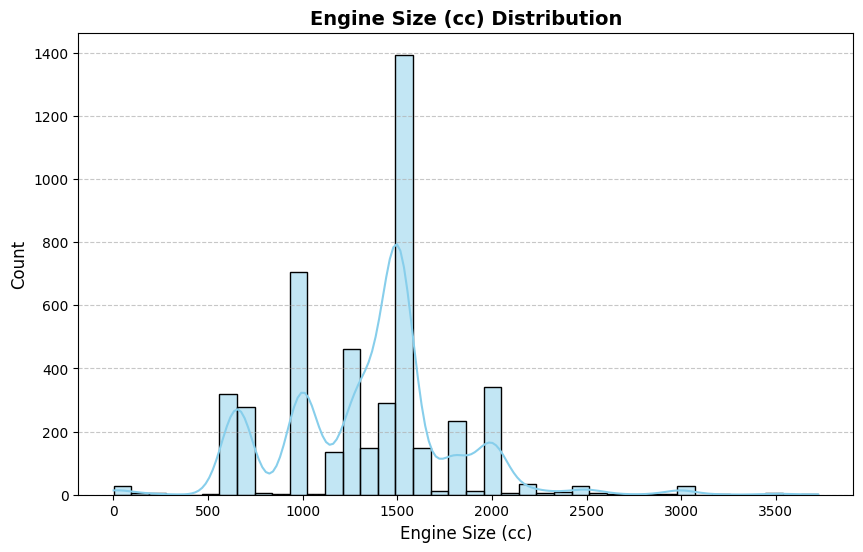

In [ ]:
# 2. Set up the figure size for better readability
plt.figure(figsize=(10, 6))

# 3. Plot with increased bins and a KDE curve to show distribution shape
sns.histplot(
    data=df, 
    x="Engine (cc)", 
    bins=40,          # More bins give a finer, smoother look
    kde=True,         # Adds a density probability curve
    color="skyblue", 
    edgecolor="black"
)

# 4. Styling the plot
plt.title("Engine Size (cc) Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Engine Size (cc)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


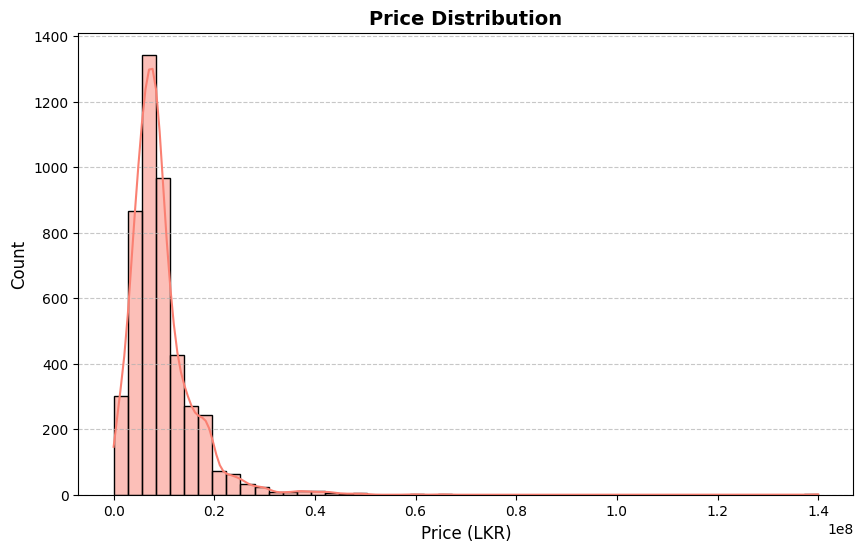

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Price_numeric",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Price Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Price (LKR)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

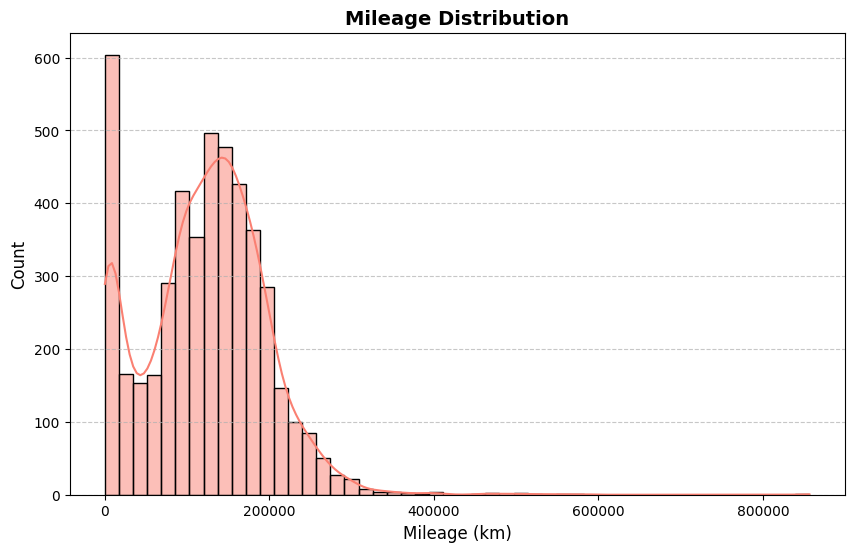

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Mileage_numeric",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Mileage Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Mileage (km)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

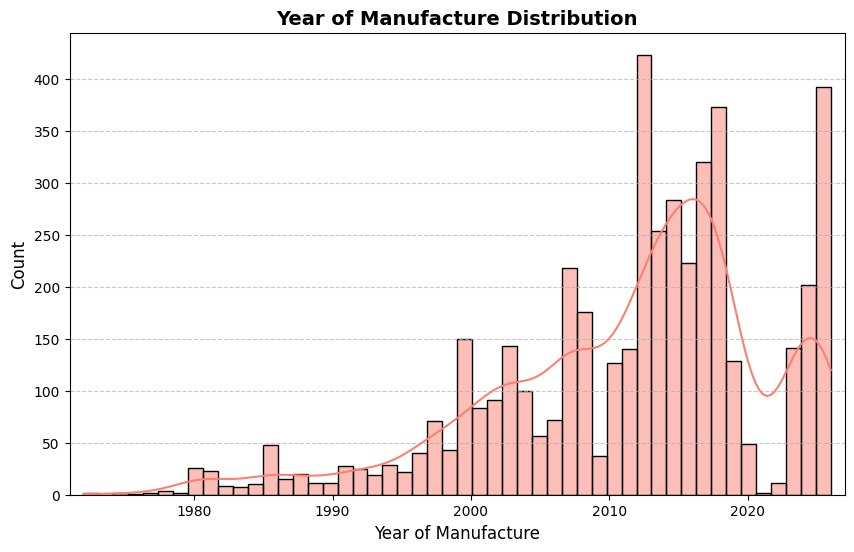

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="YOM",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Year of Manufacture Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Year of Manufacture", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xlim(df['YOM'].min() - 1, df['YOM'].max() + 1)  # Adjust x-axis limits for better visualization
plt.show()

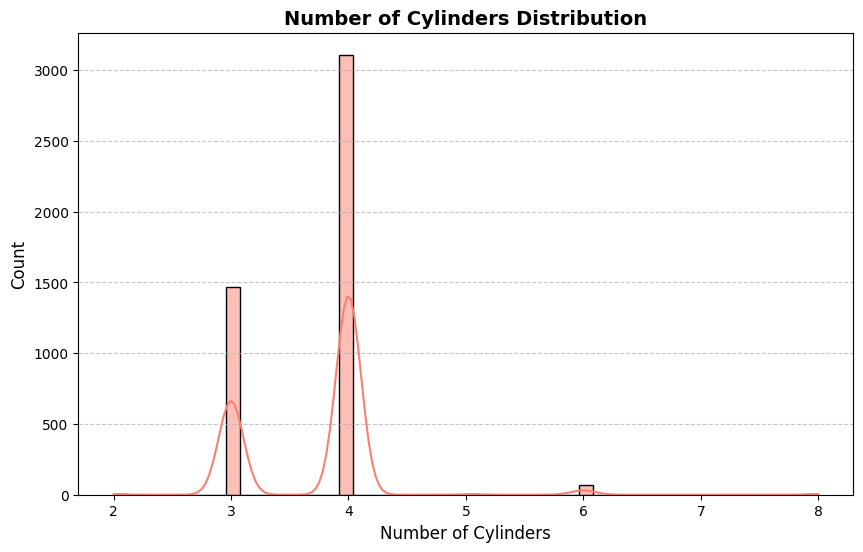

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Number of Cylinders",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Number of Cylinders Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

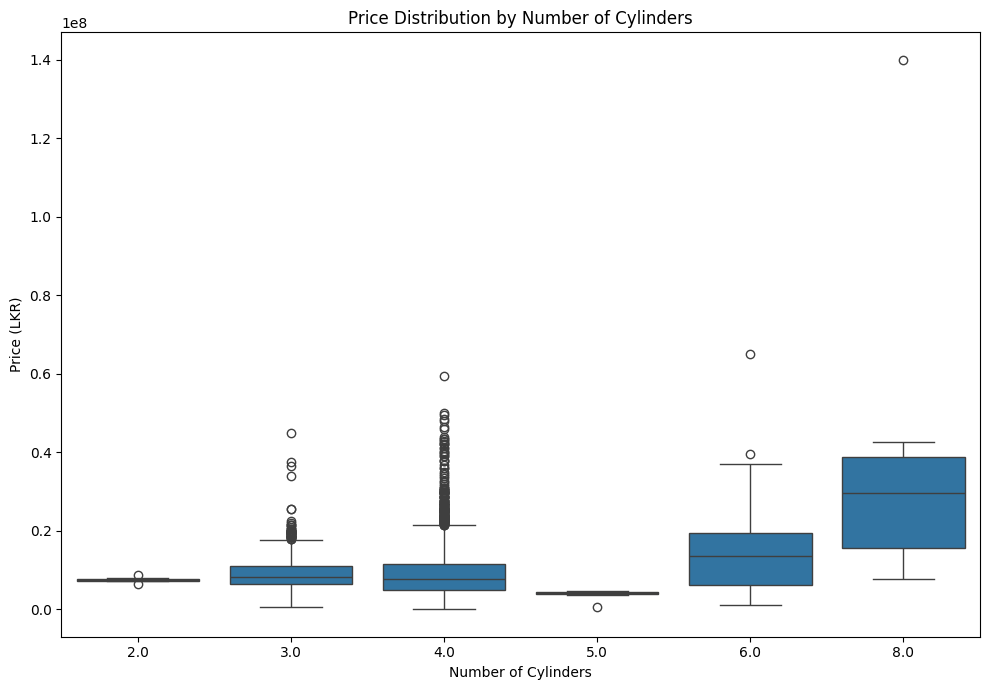

In [24]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Number of Cylinders',
    y='Price_numeric'
)

plt.title('Price Distribution by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

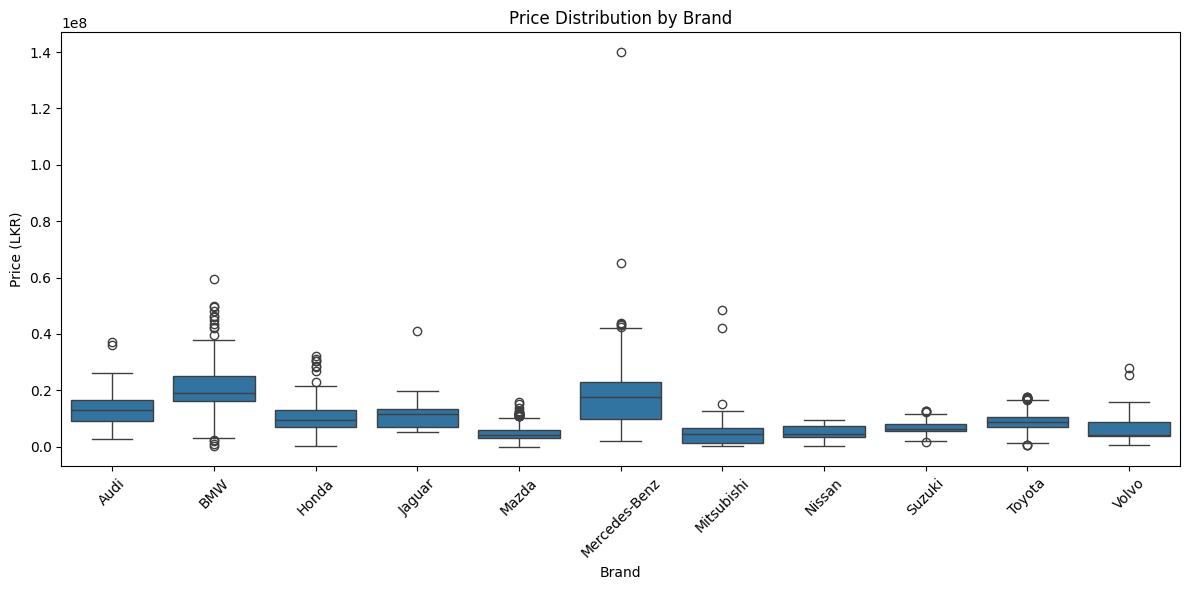

In [25]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Brand',
    y='Price_numeric'
)

plt.title('Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Price (LKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

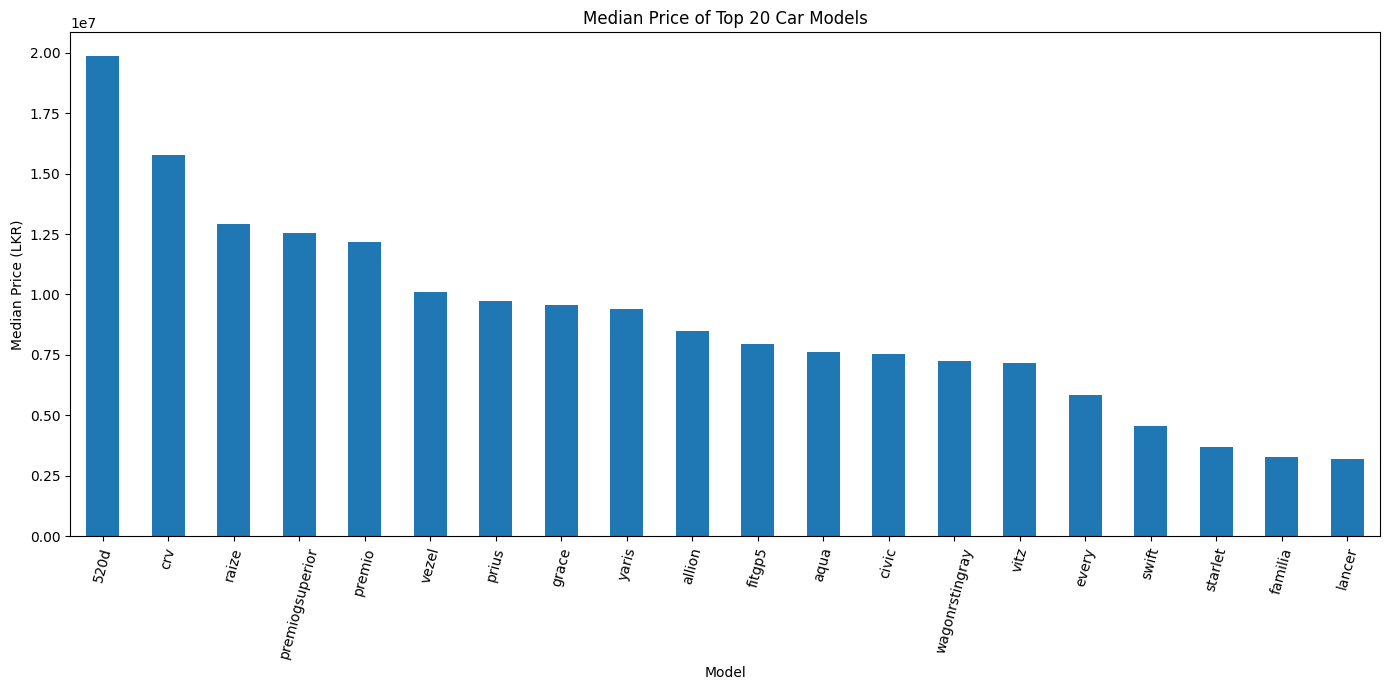

In [26]:
top_models = df['Model_cleaned'].value_counts().head(20).index
model_price = (
    df[df['Model_cleaned'].isin(top_models)]
    .groupby('Model_cleaned')['Price_numeric']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))
model_price.plot(kind='bar')

plt.title('Median Price of Top 20 Car Models')
plt.xlabel('Model')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

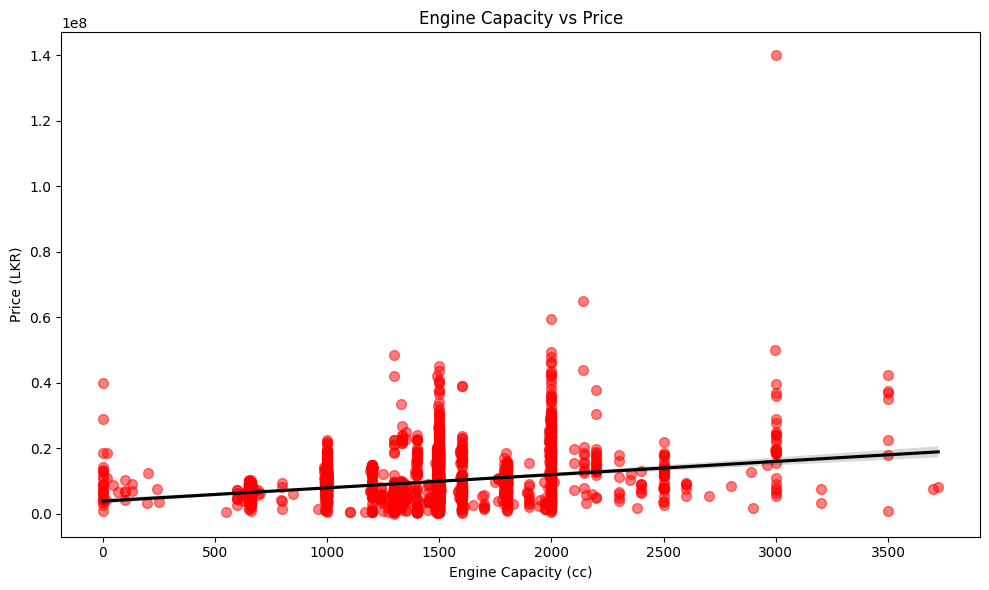

In [27]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Engine (cc)',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'s':50,'color': 'red'},
    line_kws={'color': 'black'}

)

plt.title('Engine Capacity vs Price')
plt.xlabel('Engine Capacity (cc)')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

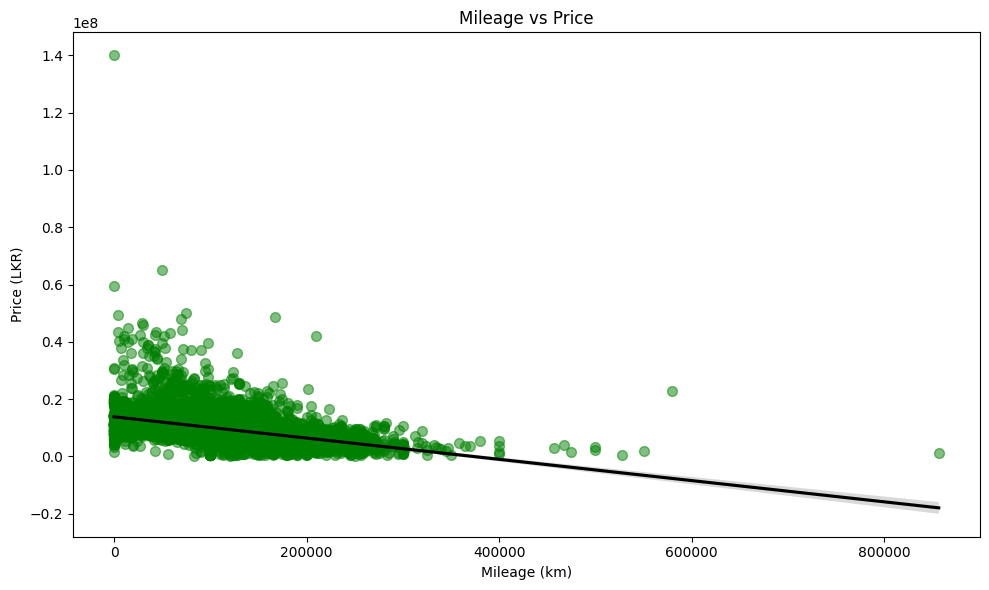

In [28]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Mileage_numeric',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'color': 'green', 's': 50},
    line_kws={'color': 'black'}
)

plt.title('Mileage vs Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

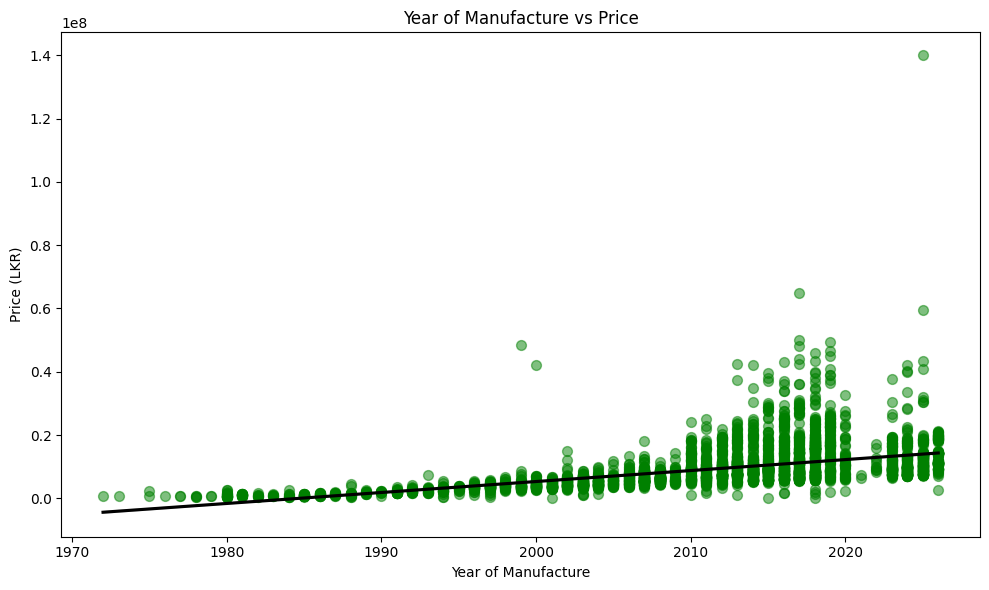

In [29]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='YOM',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'color': 'green', 's': 50},
    line_kws={'color': 'black'}
)

plt.title('Year of Manufacture vs Price')
plt.xlabel('Year of Manufacture')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

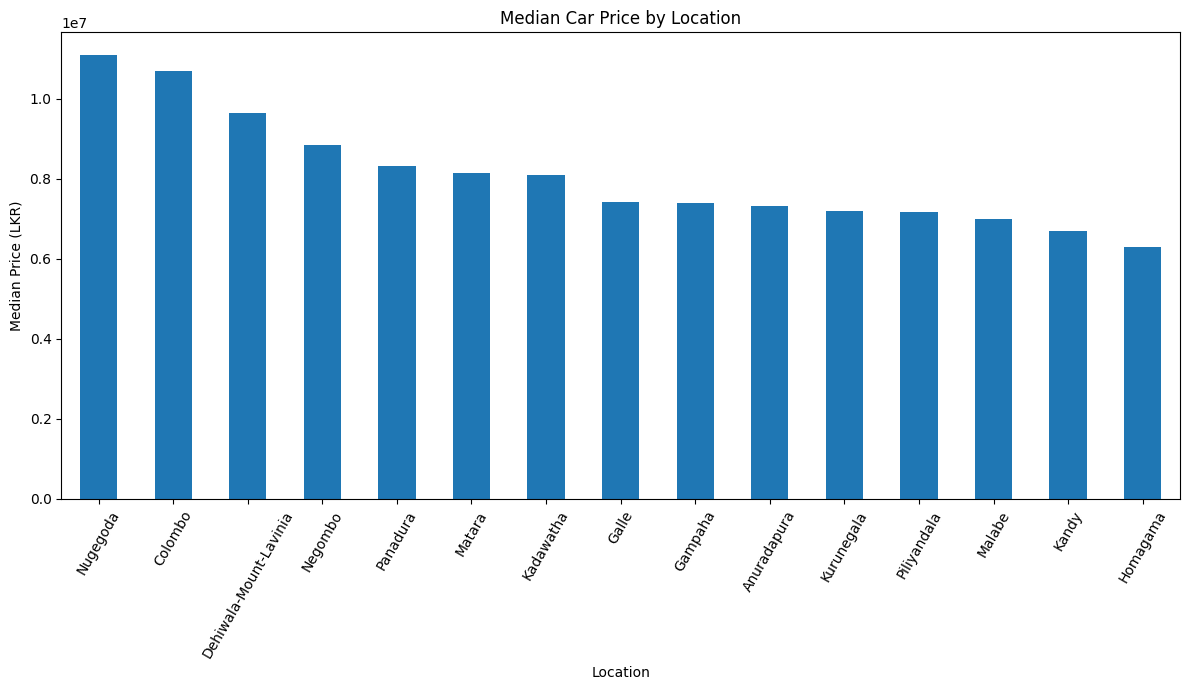

In [30]:
top_locations = df['Location'].value_counts().head(15).index
location_price = (
    df[df['Location'].isin(top_locations)]
    .groupby('Location')['Price_numeric']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

location_price.plot(kind='bar')

plt.title('Median Car Price by Location')
plt.xlabel('Location')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

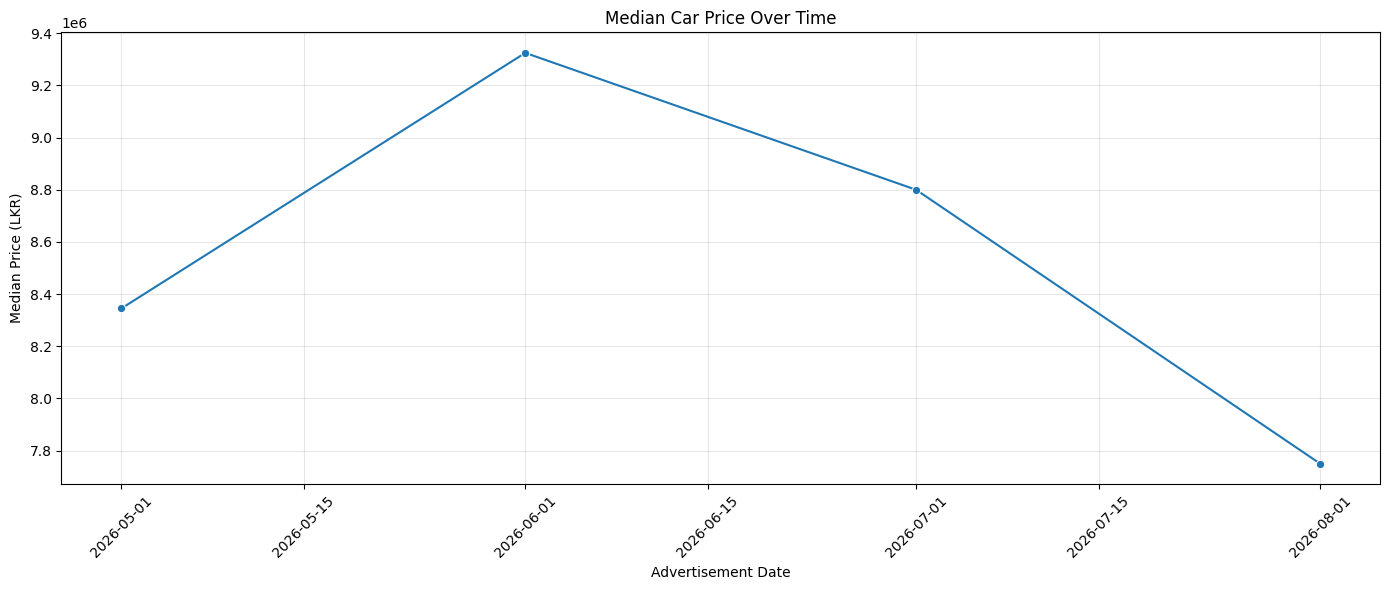

In [37]:
df['Ad_Date_clean_dt'] = pd.to_datetime(df['Ad_Date_clean'], errors='coerce')
df['Ad_Month'] = df['Ad_Date_clean_dt'].dt.to_period('M')

monthly_price = (
    df.groupby('Ad_Month')['Price_numeric']
      .median()
      .reset_index()
)

monthly_price['Ad_Month'] = monthly_price['Ad_Month'].dt.to_timestamp()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_price,
    x='Ad_Month',
    y='Price_numeric',
    marker='o'
)

plt.title('Median Car Price Over Time')
plt.xlabel('Advertisement Date')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

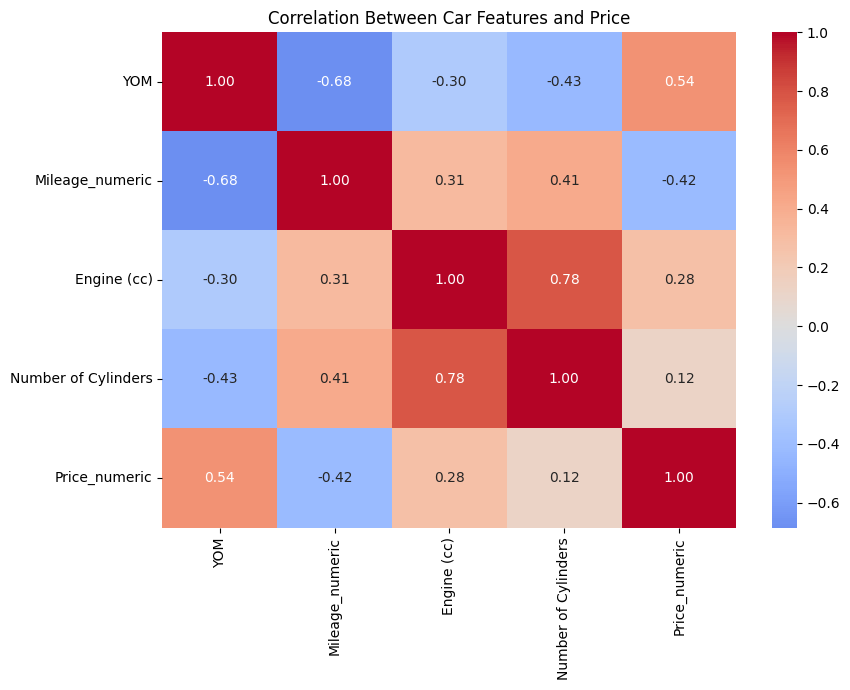

In [31]:
numeric_cols = [
    'YOM',
    'Mileage_numeric',
    'Engine (cc)',
    'Number of Cylinders',
    'Price_numeric'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Car Features and Price')
plt.tight_layout()
plt.show()

Model Building
